In [4]:
import pandas as pd
df = pd.read_csv(r"C:\\Users\\pc\\Desktop\\Ecommerce-Sales-Analytics\\Data\\Ecommerce_sales_data.csv",encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


# Data Cleaning 

# 1. Check Null Values


In [5]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

# 2. Change column name

In [6]:
df.columns = df.columns.str.replace(' ','_')


# 2. Remove Duplicates 

In [7]:
df.drop_duplicates(inplace=True)

# 3. Convert Date Columns

In [8]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], format='%d-%m-%Y')

# 4. Create Additional Columns

In [9]:
df['Year']=df['Order_Date'].dt.year
df['Month']=df['Order_Date'].dt.month_name()
df['Quarter']=df['Order_Date'].dt.quarter

# 5. Check Data Types

In [10]:
df.dtypes

Row_ID                     int64
Order_ID                  object
Order_Date        datetime64[ns]
Ship_Date         datetime64[ns]
Ship_Mode                 object
Customer_ID               object
Customer_Name             object
Segment                   object
City                      object
State                     object
Country                   object
Postal_Code              float64
Market                    object
Region                    object
Product_ID                object
Category                  object
Sub-Category              object
Product_Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping_Cost            float64
Order_Priority            object
Year                       int64
Month                     object
Quarter                    int64
dtype: object

# 6. Check Unique Values

In [11]:
df['Category'].unique()

array(['Technology', 'Furniture', 'Office Supplies'], dtype=object)

# 7. Create New Column

In [12]:
df['Profit_Margin'] = ((df['Profit'] / df['Sales']) * 100).round(2)

 # 9. Fill Missing Values

In [13]:
df['Postal_Code'] = df['Postal_Code'].fillna(0) 

# Exploratory Data Analysis (EDA)

# Sales Analysis

# 1. Total Sales

In [14]:
print(df['Sales'].sum())

12642501.909880001


# 2.Total profit

In [15]:
print(df['Profit'].sum())

1467457.29128


# 3. Monthly Sales Trend 

In [16]:
pd.options.display.float_format='{:.0f}'.format

In [17]:
monthly_sale = df.groupby('Month',as_index=False)['Sales'].sum()
monthly_sale['Sales_in_millions'] = ( monthly_sale['Sales'] / 1_000_000 ).round(2).astype(str) + 'M'
print(monthly_sale)

        Month   Sales Sales_in_millions
0       April  698561              0.7M
1      August 1293833             1.29M
2    December 1580781             1.58M
3    February  543739             0.54M
4     January  675134             0.68M
5        July  749382             0.75M
6        June 1269717             1.27M
7       March  770501             0.77M
8         May  904012              0.9M
9    November 1551277             1.55M
10    October 1168184             1.17M
11  September 1437380             1.44M


# 4.Top Selling Products

In [18]:
top_product = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_product)

Product_Name
Apple Smart Phone, Full Size                               86936
Cisco Smart Phone, Full Size                               76442
Motorola Smart Phone, Full Size                            73156
Nokia Smart Phone, Full Size                               71905
Canon imageCLASS 2200 Advanced Copier                      61600
Hon Executive Leather Armchair, Adjustable                 58193
Office Star Executive Leather Armchair, Adjustable         50662
Harbour Creations Executive Leather Armchair, Adjustable   50122
Samsung Smart Phone, Cordless                              48653
Nokia Smart Phone, with Caller ID                          47878
Name: Sales, dtype: float64


# 5. Highest Profit Categories

In [19]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

Category
Technology        663779
Office Supplies   518474
Furniture         285205
Name: Profit, dtype: float64


# 6. Loss Making Products

In [20]:
loss_product=df[df['Profit']<0]
print(loss_product[['Product_Name','Profit']])

                                            Product_Name  Profit
1              Novimex Executive Leather Armchair, Black    -289
3                         Motorola Smart Phone, Cordless     -97
9      Chromcraft Bull-Nose Wood Oval Conference Tabl...   -1862
30                             Samsung Smart Phone, VoIP    -148
32          HON 5400 Series Task Chairs for Big and Tall    -350
...                                                  ...     ...
51276  Eureka Disposable Bags for Sanitaire Vibra Gro...      -4
51278                  Stanley Highlighters, Water Color      -6
51279                   Sanford Highlighters, Easy-Erase     -21
51280                                  Boston Pens, Blue     -50
51286  Hoover Replacement Belt for Commercial Guardsm...      -1

[12544 rows x 2 columns]


# CUSTOMER ANALYSIS

# 7. Top Customers by Revenue

In [21]:
top_customer = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customer)

Customer_Name
Tom Ashbrook         40488
Tamara Chand         37457
Greg Tran            35551
Christopher Conant   35187
Sean Miller          35171
Bart Watters         32310
Natalie Fritzler     31781
Fred Hopkins         30401
Jane Waco            30288
Hunter Lopez         30244
Name: Sales, dtype: float64


# 8. Most Profitable Customers

In [22]:
df.groupby('Customer_Name')['Profit'].sum().sort_values(ascending=False).head(10)

Customer_Name
Tamara Chand      8673
Raymond Buch      8453
Sanjit Chand      8205
Hunter Lopez      7817
Bill Eplett       7410
Harry Marie       6958
Susan Pistek      6484
Mike Gockenbach   6459
Adrian Barton     6417
Tom Ashbrook      6312
Name: Profit, dtype: float64

# 9. Customer Segment Analysis

In [23]:
segment_analysis = df.groupby('Segment')['Sales'].sum()
print(segment_analysis)

Segment
Consumer      6507949
Corporate     3824698
Home Office   2309855
Name: Sales, dtype: float64


# REGIONAL ANALYSIS

# 10. Best Performing Region

In [24]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
Central          2822303
South            1600907
North            1248166
Oceania          1100185
Southeast Asia    884423
North Asia        848310
EMEA              806161
Africa            783773
Central Asia      752827
West              725458
East              678781
Caribbean         324281
Canada             66928
Name: Sales, dtype: float64


# 11. State-wise Profit Analysis

In [25]:
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False)
print(state_profit)

State
England            99908
California         76381
New York           74039
Ile-de-France      44056
New South Wales    43696
                   ...  
Izmir             -15730
Ohio              -16971
Texas             -25729
Lagos             -25923
Istanbul          -29034
Name: Profit, Length: 1094, dtype: float64


# SHIPPING ANALYSIS

# 12. Average Shipping Cost

In [26]:
avg_shipping =  df['Shipping_Cost'].mean()
print(avg_shipping)

26.375915188146305


In [27]:
shipping_cost = df.groupby('Ship_Mode')['Shipping_Cost'].sum().sort_values(ascending=False)
print(shipping_cost)

Ship_Mode
Standard Class   614631
Second Class     314113
First Class      308103
Same Day         115974
Name: Shipping_Cost, dtype: float64


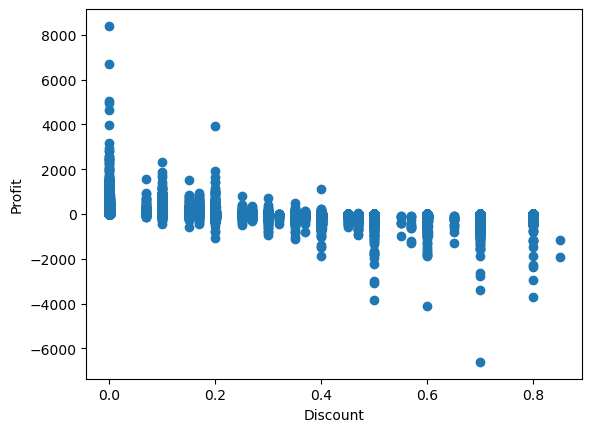

In [28]:
import matplotlib.pyplot as plt

plt.scatter(df['Discount'], df['Profit'])
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

In [29]:
df.to_csv(r"C:\\Users\\pc\\Desktop\\Ecommerce-Sales-Analytics\\Data\\Cleaned_Ecommerce_sales_data.csv", index=False)